<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Feature Scaling Transformation


---

### Learning Objectives
- Explain the benefits of scaling data.
- Identify situations where scaling data is beneficial. 
- Scale data using Python and SKLearn.

<a id='intro'></a>

## Introduction to feature scaling

---

Scaling data is the process of **increasing or decreasing the magnitude** according to a fixed ratio. In other words, you **change the size but not the shape** of the data (the shape of the distribution is unchanged).

Some data scaling methods often change the *location* of the data as well. For example, when **"centering"** we take a distribution and **change it's mean to be zero by subtracting the mean of the distribution from each data point** in the distribution. While this is not technically "scaling", changing the location is often a component of the process and preserves the shape of the data (it just shifts it around).


<a id='why-scale'></a>

## Why should we scale data?

---

**There are a number of good reasons why we scale our data:**
- To handle differences in units.
- Cut computational expense.
- Improve model performance (Especially Machine Learning).
- We scale for models to prevent the steps on different axes from varying widely.

**It’s rarely a bad idea to scale your data!** 

<a id='centering'></a>

## Centering: changing the location of data

---

We can start with the simplest transformation example: centering. If we have a distribution of values $X$, then to center our data to a new distribution $X_c$:

### $$ X_c = X - \bar{X} $$

### Benefits of centering data

Centering is particularly crucial when dealing with features that have different baseline values. By centering, we eliminate biases introduced by varying means and help our model focus on the relative differences between data points.

*Centering typically means rescales data to have a mean of 0*.




<a id='standardization'></a>

## Standardization (Z-score normalization)

---

The **most common method** of scaling is standardization. In standardization we first center the data, then we divide by the standard deviation to enforce that the standard deviation of the variable is one:

### $$ X_{std} = \frac{X - \bar{X}}{s_{X}} $$

*Standardization typically means rescales data to have a **mean of 0** and a **standard deviation of 1** (unit variance)*.

### Benefits of standardizing data

There are many benefits to standardizing our data, especially when we have more than one predictor:
- Intercepts are interpreted as the estimate when all predictors are at their mean value.
- Coefficients are in units of standard deviations of the original predictors. This allows for direct comparison of the magnitude of impact between different predictors.
- Optimization methods (minimizing loss functions) are faster and more stable.
- In K-Nearest Neighbors methods it is necessary if you want features to contribute equally since these models use the distance between observations calculated from the features.
- In logistic regression, neural networks, and support vector machines unscaled data can result in a disproportionate effect of some data points over others.

> **Note:** In ordinary linear regression centering and scaling your variables does *not* impact the amount of variance you can account for. This is because we are only moving and and adjusting the magnitude of the distribution: the shape of the distribution does not change.



In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
# %matplotlib inline

# %autosave 0

### Standardization example


Load in the dataset on the heights, weights, and ages of baseball players.

In [4]:
baseball = pd.read_csv('./data/baseball_height_weight.csv')
baseball.head()

,name,team,position,height_in,weight_lb,age
0,Adam_Donachie,BAL,Catcher,74,180.0,22.99
1,Paul_Bako,BAL,Catcher,74,215.0,34.69
2,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78
3,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43
4,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71


First, plot the original `height` variable against the `weight` variable. Use seaborn's `sns.jointplot`. 

In [1]:
# First, plot the original height variable against the weight variable.
# Use seaborn's sns.jointplot



**Create standardized versions of the height and weight variables.**

In [6]:
# Manual calculation of standardization
baseball['height_in_std'] = (baseball.height_in - baseball.height_in.mean()) / baseball.height_in.std()
baseball['weight_lb_std'] = (baseball.weight_lb - baseball.weight_lb.mean()) / baseball.weight_lb.std()

In [7]:
# show the head
baseball.head()

,name,team,position,height_in,weight_lb,age,height_in_std,weight_lb_std
0,Adam_Donachie,BAL,Catcher,74,180.0,22.99,0.131042,-1.032276
1,Paul_Bako,BAL,Catcher,74,215.0,34.69,0.131042,0.634874
2,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78,-0.735850,0.396710
3,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43,-0.735850,0.396710
4,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71,-0.302404,-0.651213


**Plot the standardized weight against the height. Notice the distribution shapes and relationship between the variables is unchanged.**

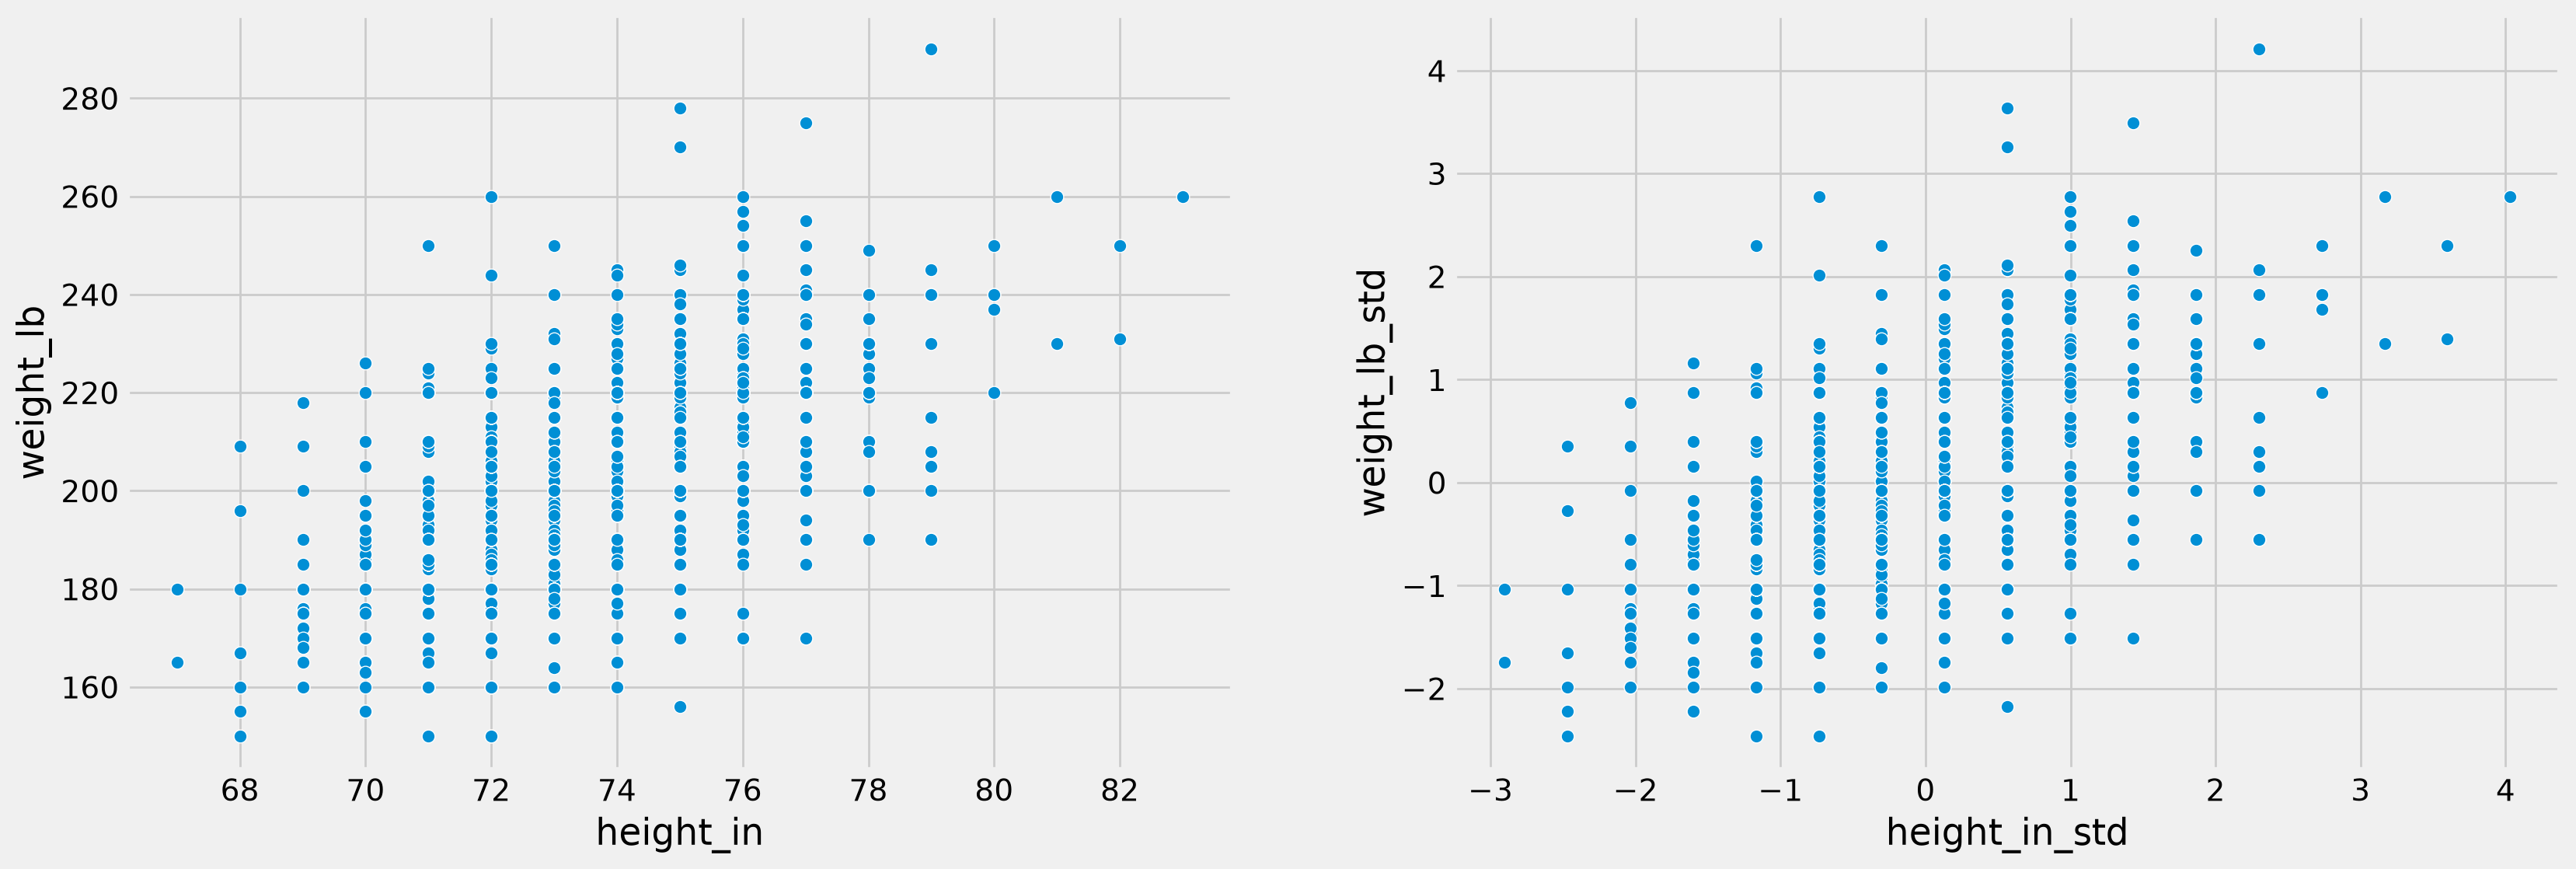

In [8]:
# Let's before Standardization and after Standardization together to compare
fig, ax = plt.subplots(1,2,figsize=(18,6))
sns.scatterplot(x=baseball.height_in, y=baseball.weight_lb,ax=ax[0])
sns.scatterplot(x=baseball.height_in_std, y=baseball.weight_lb_std,ax=ax[1]);

# Remember, you can modify the xlabel and the y label if you want using:
# ax[0].set(xlabel='your xlabel', ylabel='your ylabel')
# ax[1].set(xlabel='your xlabel', ylabel='your ylabel')


<a id='standard-scaler'></a>
### Using sklearn's `StandardScaler`

Sklearn comes packaged with a class `StandardScaler` that will preform the standardization on a matrix for you. 

Load in the package like so:

```python
from sklearn.preprocessing import StandardScaler
```

Once instantiated, the standard scaler object has three primary methods built in:
- `.fit(X)` will calculate the mean and standard deviations for each column of X
- `.transform(X)` will take X and return a transformed version of X where each column is standardized according to their means and standard deviations (must have run `.fit()` first).
- `.fit_transform(X)` combines the `.fit()` method and the `.transform()` method.

**Use `StandardScaler` to standardize a predictor matrix containing height and weight from the baseball data.**

In [9]:
# Let's setup new predictors X and new target y



In [10]:
# get train-test split



In [12]:
# Import StandardScaler 
from sklearn.preprocessing import StandardScaler

# instantiate the Scaler



In [14]:
# Fit the data using the scaler (scale the data)





# print ('mean after standardization:',X_train_std.mean())
# print ('standard deviation after standardization:',X_train_std.std())



### Important Note:

---

- In the interest of preventing information about the distribution of the test set leaking into your model,`you should  fit the scaler on your training data only, then transform both training and test sets with that scaler`. By fitting the scaler on the full dataset prior to splitting, information about the test set is used to transform the training set, which in turn is passed downstream.

- As an example, knowing the distribution of the whole dataset might influence how you detect and process outliers, as well as how you parameterise your model. Although the data itself is not exposed, information about the distribution of the data is. As a result, your test set performance is not a true estimate of performance on unseen data


> "*Again, it is emphasized that the statistics required for the transformation (e.g., the mean) are estimated from the training set and are applied to all data sets (e.g., the test set or new samples)*".
Page 124, [Feature Engineering and Selection, 2019](https://amzn.to/2Yvcupn).



**Build a linear regression predicting age from the standardized height and weight data. Interpret the coefficients.**

In [15]:
# building a linear regression without standrized data



# print('Intercept:', lr.intercept_)
# print('Coefs:', lr.coef_)
# print('Score:',lr.score(X_train, y_train))

In [16]:
# building a linear regression with standrized data


# print('Intercept:', lr_std.intercept_)
# print('Coefs:', lr_std.coef_)
# print('Score:',lr_std.score(X_train_std, y_train))

<a id='normalization'></a>

## Normalization

---

Normalization most often refers to the process of "normalizing" a variable to be between 0 and 1. Think of this as squishing the variable to be constrained to a specific range.

### $$ X_{norm} = \frac{X - min(X)}{max(X) - min(X)} $$

This type of normalization is typically referred to as "min-max scaling". 

### Benefits of normalization

Typically standardization is preferred to min-max normalization. However, there are some applications where min-max scaling would be preferable:
- Neural networks often require their inputs to be bounded between 0 and 1. 
- In images, for example, where pixels can only take on a specific range of RGB values, data may have to be normalized.

<a id='minmax'></a>
### Normalization with `MinMaxScaler`

Sklearn also has a class for normalization called `MinMaxScaler`:

```python
from sklearn.preprocessing import MinMaxScaler
```

The `MinMaxScaler` has the same `fit()`, `transform()`, and `fit_transform()` methods.

**Normalize the height, and weight variables using `MinMaxScaler`**

In [13]:
# Recall what were the predictors and the target
# X = baseball[['height_in', 'weight_lb']]
# y = baseball.age

In [14]:
# Recall the train-test split we did earlier
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=1) 

In [17]:
# Importing MinMaxScaler to do Normalization
from sklearn.preprocessing import MinMaxScaler

# instantiate the scaler.



In [17]:
# Fit the data using the MinMaxScaler (scale the data).



**Look at the min and max ranges for the normalized matrix.**

In [19]:
# what is the minimum range for the normalized matrix



In [20]:
# what is the maximum range for the normalized matrix


In [21]:
X_train_norm

array([[0.2       , 0.32      ],
       [0.46666667, 0.56      ],
       [0.2       , 0.36      ],
       ...,
       [0.26666667, 0.48      ],
       [0.46666667, 0.24      ],
       [0.53333333, 0.608     ]], shape=(722, 2))

**Build a linear regression predicting age from the Normalized height and weight data. Interpret the coefficients.**

In [21]:
# building a linear regression with Normalized data



# print('Intercept:', lr_norm.intercept_)
# print('Coefs:', lr_norm.coef_)
# print('Score:',lr_norm.score(X_train_norm, y_train))

<a id='resources'></a>

## Additional resources

---

[About feature scaling and normalization.](http://sebastianraschka.com/Articles/2014_about_feature_scaling.html)